In [2]:
import meshio
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import pandas as pd


import sys
sys.path.append(r"C:\Users\gabri\Documents\thesis\SPlisHSPlasH\build\lib\Release")  # where pysplishsplash.pyd lives

import pysplishsplash as sph
import pysplishsplash.Utilities.SceneLoaderStructs as Scenes

In [4]:
sph.SimulatorBase()

AttributeError: module 'pysplishsplash' has no attribute 'SimulatorBase'

In [ ]:
splishsplash_path = 'C:/Users/gabri/Documents/thesis/SPlisHSPlasH/'
scenes_path = splishsplash_path + 'data/Scenes/'
output_path = splishsplash_path + 'bin/output'

In [ ]:
## Simulation setup

scene = 'DamBreakModelDragons'

In [15]:

def main():
    # Set up the simulator
    base = sph.Exec.SimulatorBase()
    base.init(useGui=False,  sceneFile=sph.Extras.Scenes.Empty)

    # Create an imgui simulator
    # gui = sph.GUI.Simulator_GUI_imgui(base)
    # base.setGui(gui)

    # Get the scene and add objects
    scene = sph.Exec.SceneConfiguration.getCurrent().getScene()
    scene.boundaryModels.append(Scenes.BoundaryData(meshFile="C:/Users/gabri/Documents/thesis/SPlisHSPlasH/data/models/UnitBox.obj"))
    # scene.fluidBlocks.append(Scenes.FluidBlock(id='Fluid', boxMin = [-1.5, 0.0, -1.5], boxMax = [-0.5, 2.0, -0.5], mode=0, initialVelocity=[0.0, 0.0, 0.0]))
    # scene.fluidBlocks.append(Scenes.FluidBlock(id='Fluid', boxMin = [0.5, 0.0, 0.5], boxMax = [1.5, 2.0, 1.5], mode=0, initialVelocity=[0.0, 0.0, 0.0]))

    # Run the GUI
    # base.run()

In [ ]:

main()


: 

In [ ]:
# scene_json = scenes_path + scene + '.json'

# custom_scene = os.path.abspath(scene_json)
# base.init(sceneFile=custom_scene)

In [ ]:
folders = os.listdir(output_path + '/' + scene)
folders.remove('log')
print(folders)

folders_no_visc = list(filter(lambda k: 'no_visc' in k, folders))
print(folders_no_visc)

folders_005_visc = list(filter(lambda k: 'visc_005' in k, folders))
print(folders_005_visc)

test_folder = ['vtk_vr_13_visc_005']
compare_dfsph = ['vtk_vr_13_visc_005','vtk_dfsph_visc_005','vtk']

new_folder = ['vtk_mp_02_visc_005_testing_diss', 'vtk_vr_13_visc_005_testing_diss']

['vtk_dfsph_visc_005', 'vtk_mp_00_no_visc', 'vtk_mp_00_visc_005', 'vtk_mp_02_no_visc', 'vtk_mp_02_visc_005', 'vtk_mp_02_visc_005_testing_diss', 'vtk_vr_00_no_visc', 'vtk_vr_00_visc_005', 'vtk_vr_13_no_visc', 'vtk_vr_13_visc_005', 'vtk_vr_13_visc_005_testing_diss', 'vtk_vr_no_visc_but_visc_005']
['vtk_mp_00_no_visc', 'vtk_mp_02_no_visc', 'vtk_vr_00_no_visc', 'vtk_vr_13_no_visc', 'vtk_vr_no_visc_but_visc_005']
['vtk_dfsph_visc_005', 'vtk_mp_00_visc_005', 'vtk_mp_02_visc_005', 'vtk_mp_02_visc_005_testing_diss', 'vtk_vr_00_visc_005', 'vtk_vr_13_visc_005', 'vtk_vr_13_visc_005_testing_diss', 'vtk_vr_no_visc_but_visc_005']


In [107]:
full_path = output_path + '/' + scene + '/vtk_mp_02_visc_005_testing_diss/'
files = os.listdir(full_path)
file = 'ParticleData_Fluid_1.vtk'
mesh = meshio.read(full_path + file)
print(mesh)

<meshio mesh object>
  Number of points: 21299
  Number of cells:
    vertex: 21299
  Point data: id, density, velocity, vorticity_current, mass, vorticity_dissipation, vorticity_linear_field, stream, delta_velocity, m_pre_vi, m_post_vi


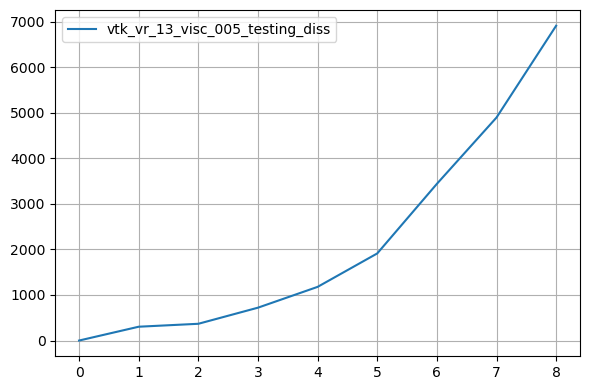

In [113]:
plt.figure(figsize=(6, 4))
for folder in new_folder:
    full_path = output_path + '/' + scene + '/' + folder + '/'
    files = os.listdir(full_path)

    enstrophy = []
    # kin_energy = []
    avg_vort = []
    var_vort = []
    tot_vort_diss = []
    tot_vort_lin = []
    tot_vort_final = []
    tot_stream = []
    avg_delt_v = []
    avg_velocity = []
    percent_v = []
    avg_stream = []
    avg_percent = []
    min_delta_v = []
    max_delta_v = []
    percent_vort_dissip = []
    volume = []
    diff_velocity = []
    v_antes = []
    v_depois = []
    max_vort = []
    for i in range(1,10):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)
        mesh = meshio.read(full_path + file)
        vorticity_current = mesh.point_data['vorticity_current']
        mass = mesh.point_data['mass']
        density = mesh.point_data['density']
        velocity = mesh.point_data['velocity']
        vorticity_dissip = mesh.point_data['vorticity_dissipation']
        # vorticity_linear = mesh.point_data['vorticity_linear_field']
        # delta_velocity = mesh.point_data['delta_velocity']
        # m_pre_vi = mesh.point_data['m_pre_vi']
        # m_post_vi = mesh.point_data['m_post_vi']
        # stream = mesh.point_data['stream']
        particle_numbers = len(mesh.point_data['velocity'])
        # enstrophy.append(np.sum((mass/density) * norm(vorticity_current, axis=1)**2 / 2))
        # this_avg_vort = np.sum(norm(vorticity_current, axis=1))/particle_numbers
        # avg_vort.append(this_avg_vort)
        # var_vort.append(np.sum((norm(vorticity_current, axis=1) - this_avg_vort)**2))
        # kin_energy.append(np.sum(mass * norm(velocity)**2 /2))
        # volume.append(np.average(mass)/np.average(density))
        tot_vort_diss.append(np.sum(norm(vorticity_dissip, axis=1)))
        # tot_vort_lin.append(np.sum(norm(vorticity_linear, axis=1)))
        tot_vort_final.append(np.sum(norm(vorticity_current, axis=1)))
        max_vort.append(np.max(norm(vorticity_current, axis=1)))
        # percent_vort_dissip.append(np.average(norm(vorticity_dissip, axis=1)/norm(vorticity_current, axis=1)))

        avg_velocity.append(np.average(norm(velocity, axis=1)))
        # v_depois.append(np.average(norm(m_post_vi, axis=1)))
        # v_antes.append(np.average(norm(m_pre_vi, axis=1)))
        # avg_delt_v.append(np.average(norm(delta_velocity, axis=1)))
        # diff_velocity.append(np.sum(norm((m_post_vi - m_pre_vi)/1.3, axis=1)))
        # avg_stream.append(np.average(norm(stream, axis=1)))
 
        # avg_percent.append((np.average(norm(delta_velocity, axis=1)/norm(velocity, axis=1))))
        # min_delta_v.append(np.min(norm(delta_velocity)))
        # max_delta_v.append(np.max(norm(delta_velocity)))
        # tot_vort_diss.append(np.max(vorticity_dissip[0]))
        # tot_vort_diss.append(np.min(vorticity_dissip[0]))

    # plt.plot(max_vort, label=folder)   # first line
    # plt.plot(tot_vort_lin, label='lin')
    plt.plot(tot_vort_diss, label=folder)
    # plt.plot(percent_vort_dissip, label='percent_vort_dissip')
    # plt.plot(avg_velocity, label = 'avg_vel')
    # plt.plot(v_depois, label = 'v_depois')
    # plt.plot(v_antes, label = 'v_antes')
    # plt.plot(avg_percent, label = folder)
    # plt.plot(avg_delt_v, label = 'avg_delta_vel')
    # plt.plot(diff_velocity, label = 'diff_velocity')
    # plt.plot(enstrophy, label=folder)
    # plt.plot(min_delta_v, label = 'min_delta_v')
    # plt.plot(max_delta_v, label = 'max_delta_v') #0.001

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()
        

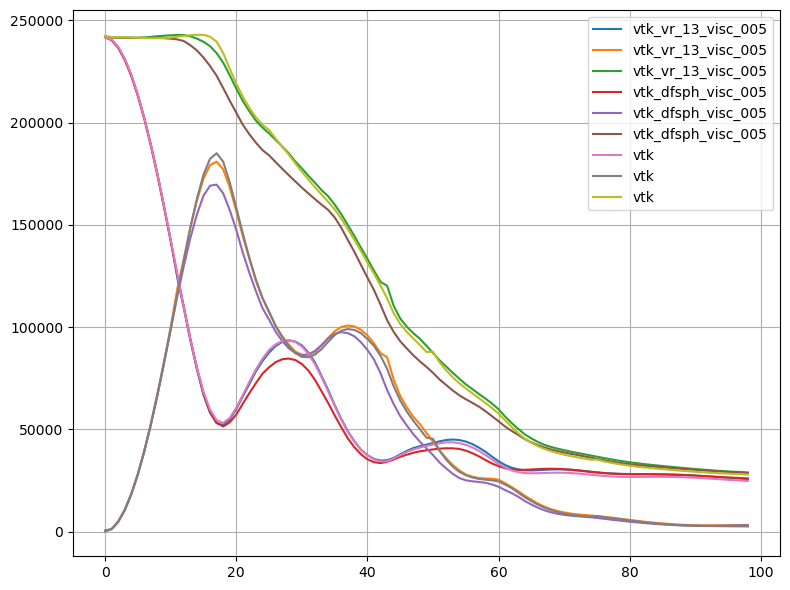

In [89]:
plt.figure(figsize=(8, 6))
for folder in compare_dfsph:
    full_path = output_path + '/' + scene + '/' + folder + '/'
    files = os.listdir(full_path)

    # enstrophy = []
    kin_energy = []
    pot_energy = []
    total_energy = []
    for i in range(1,100):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)
        mesh = meshio.read(full_path + file)
        # vorticity_current = mesh.point_data['vorticity_current']
        mass = mesh.point_data['mass']
        density = mesh.point_data['density']
        velocity = mesh.point_data['velocity']
        h = mesh.points[:,1]
        aux_pot_energy = np.sum(mass * h * 9.81)
        pot_energy.append(aux_pot_energy)
        # enstrophy.append(np.sum((mass/density) * norm(vorticity_current, axis=1)**2))
        aux_kin_energy = np.sum(mass * norm(velocity, axis=1)**2 /2)
        kin_energy.append(aux_kin_energy)
        total_energy.append(aux_pot_energy + aux_kin_energy)
    plt.plot(pot_energy, label=folder)   # first line
    plt.plot(kin_energy, label=folder)
    plt.plot(total_energy, label=folder)

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

## No Vort

In [67]:
full_path = base_path + '/' + simulation + '/vtk_no_vort_algo/'
# print(full_path)
files = os.listdir(full_path)
print(files)

['ParticleData_Fluid_1.vtk', 'ParticleData_Fluid_10.vtk', 'ParticleData_Fluid_100.vtk', 'ParticleData_Fluid_101.vtk', 'ParticleData_Fluid_102.vtk', 'ParticleData_Fluid_103.vtk', 'ParticleData_Fluid_104.vtk', 'ParticleData_Fluid_105.vtk', 'ParticleData_Fluid_106.vtk', 'ParticleData_Fluid_107.vtk', 'ParticleData_Fluid_108.vtk', 'ParticleData_Fluid_109.vtk', 'ParticleData_Fluid_11.vtk', 'ParticleData_Fluid_110.vtk', 'ParticleData_Fluid_111.vtk', 'ParticleData_Fluid_112.vtk', 'ParticleData_Fluid_113.vtk', 'ParticleData_Fluid_114.vtk', 'ParticleData_Fluid_115.vtk', 'ParticleData_Fluid_116.vtk', 'ParticleData_Fluid_117.vtk', 'ParticleData_Fluid_118.vtk', 'ParticleData_Fluid_119.vtk', 'ParticleData_Fluid_12.vtk', 'ParticleData_Fluid_120.vtk', 'ParticleData_Fluid_121.vtk', 'ParticleData_Fluid_122.vtk', 'ParticleData_Fluid_123.vtk', 'ParticleData_Fluid_124.vtk', 'ParticleData_Fluid_125.vtk', 'ParticleData_Fluid_126.vtk', 'ParticleData_Fluid_127.vtk', 'ParticleData_Fluid_128.vtk', 'ParticleData_

In [68]:
enstrophy_base = []
kin_energy_base = []
for i in range(1,200):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)
    mesh = meshio.read(full_path + file)
    vorticity_current = mesh.point_data['vorticity_current']
    mass = mesh.point_data['mass']
    density = mesh.point_data['density']
    velocity = mesh.point_data['velocity']
    enstrophy_base.append(np.sum((mass/density) * norm(vorticity_current, axis=1)**2))
    kin_energy_base.append(np.sum(mass * norm(velocity)**2 /2))
    
print(enstrophy_base)

[np.float32(0.0), np.float32(4.1408886e-05), np.float32(0.6320442), np.float32(11.033714), np.float32(25.932405), np.float32(44.050808), np.float32(158.65056), np.float32(290.12146), np.float32(326.6588), np.float32(273.16052), np.float32(225.51245), np.float32(176.67561), np.float32(138.12692), np.float32(106.24491), np.float32(84.520996), np.float32(70.331024), np.float32(60.18907), np.float32(53.004467), np.float32(48.3211), np.float32(44.271904), np.float32(41.66634), np.float32(40.13453), np.float32(41.201313), np.float32(50.3336), np.float32(89.43938), np.float32(89.04762), np.float32(77.22194), np.float32(86.9762), np.float32(85.372795), np.float32(87.61868), np.float32(92.941055), np.float32(70.843575), np.float32(77.92126), np.float32(80.64455), np.float32(67.26199), np.float32(71.6995), np.float32(86.35246), np.float32(76.91753), np.float32(67.22264), np.float32(68.81425), np.float32(73.939964), np.float32(80.329956), np.float32(89.33479), np.float32(148.0102), np.float32(435

## MP

In [69]:
full_path = base_path + '/' + simulation + '/vtk_basemp_noavx_w_base_visc/'
# print(full_path)
files = os.listdir(full_path)
print(files)

['ParticleData_Fluid_1.vtk', 'ParticleData_Fluid_10.vtk', 'ParticleData_Fluid_100.vtk', 'ParticleData_Fluid_101.vtk', 'ParticleData_Fluid_102.vtk', 'ParticleData_Fluid_103.vtk', 'ParticleData_Fluid_104.vtk', 'ParticleData_Fluid_105.vtk', 'ParticleData_Fluid_106.vtk', 'ParticleData_Fluid_107.vtk', 'ParticleData_Fluid_108.vtk', 'ParticleData_Fluid_109.vtk', 'ParticleData_Fluid_11.vtk', 'ParticleData_Fluid_110.vtk', 'ParticleData_Fluid_111.vtk', 'ParticleData_Fluid_112.vtk', 'ParticleData_Fluid_113.vtk', 'ParticleData_Fluid_114.vtk', 'ParticleData_Fluid_115.vtk', 'ParticleData_Fluid_116.vtk', 'ParticleData_Fluid_117.vtk', 'ParticleData_Fluid_118.vtk', 'ParticleData_Fluid_119.vtk', 'ParticleData_Fluid_12.vtk', 'ParticleData_Fluid_120.vtk', 'ParticleData_Fluid_121.vtk', 'ParticleData_Fluid_122.vtk', 'ParticleData_Fluid_123.vtk', 'ParticleData_Fluid_124.vtk', 'ParticleData_Fluid_125.vtk', 'ParticleData_Fluid_126.vtk', 'ParticleData_Fluid_127.vtk', 'ParticleData_Fluid_128.vtk', 'ParticleData_

In [70]:
enstrophy_mp = []
kin_energy_mp = []
for i in range(1,200):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)
    mesh = meshio.read(full_path + file)
    vorticity_current = mesh.point_data['vorticity_current']
    mass = mesh.point_data['mass']
    density = mesh.point_data['density']
    velocity = mesh.point_data['velocity']
    enstrophy_mp.append(np.sum((mass/density) * norm(vorticity_current, axis=1)**2))
    kin_energy_mp.append(np.sum(mass * norm(velocity)**2 /2))
    
print(enstrophy_mp)

[np.float32(0.0), np.float32(4.1408886e-05), np.float32(0.6320443), np.float32(11.033732), np.float32(25.93235), np.float32(44.054714), np.float32(158.63939), np.float32(290.19086), np.float32(326.6703), np.float32(273.1745), np.float32(225.40826), np.float32(176.79025), np.float32(138.16965), np.float32(106.411095), np.float32(84.53133), np.float32(70.43608), np.float32(60.460648), np.float32(52.80465), np.float32(48.671535), np.float32(44.60736), np.float32(41.426445), np.float32(40.184242), np.float32(40.689655), np.float32(50.730854), np.float32(89.92229), np.float32(88.7217), np.float32(80.59979), np.float32(86.460075), np.float32(86.66736), np.float32(89.7817), np.float32(91.00154), np.float32(69.50958), np.float32(77.74102), np.float32(79.95961), np.float32(67.81254), np.float32(70.987885), np.float32(88.049934), np.float32(78.2576), np.float32(69.29509), np.float32(72.67755), np.float32(75.991516), np.float32(83.4546), np.float32(94.152466), np.float32(153.04706), np.float32(44

## Vort Ref Changing Loop Order

In [71]:
full_path = base_path + '/' + simulation + '/vtk_vr_vorticity_order/'
print(full_path)
files = os.listdir(full_path)
print(files)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/bin/output/DamBreakModel/vtk_vr_vorticity_order/
['ParticleData_Fluid_1.vtk', 'ParticleData_Fluid_10.vtk', 'ParticleData_Fluid_100.vtk', 'ParticleData_Fluid_101.vtk', 'ParticleData_Fluid_102.vtk', 'ParticleData_Fluid_103.vtk', 'ParticleData_Fluid_104.vtk', 'ParticleData_Fluid_105.vtk', 'ParticleData_Fluid_106.vtk', 'ParticleData_Fluid_107.vtk', 'ParticleData_Fluid_108.vtk', 'ParticleData_Fluid_109.vtk', 'ParticleData_Fluid_11.vtk', 'ParticleData_Fluid_110.vtk', 'ParticleData_Fluid_111.vtk', 'ParticleData_Fluid_112.vtk', 'ParticleData_Fluid_113.vtk', 'ParticleData_Fluid_114.vtk', 'ParticleData_Fluid_115.vtk', 'ParticleData_Fluid_116.vtk', 'ParticleData_Fluid_117.vtk', 'ParticleData_Fluid_118.vtk', 'ParticleData_Fluid_119.vtk', 'ParticleData_Fluid_12.vtk', 'ParticleData_Fluid_120.vtk', 'ParticleData_Fluid_121.vtk', 'ParticleData_Fluid_122.vtk', 'ParticleData_Fluid_123.vtk', 'ParticleData_Fluid_124.vtk', 'ParticleData_Fluid_125.vtk', 'ParticleD

In [72]:
enstrophy_vr = []
kin_energy_vr = []
for i in range(1,200):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)
    mesh = meshio.read(full_path + file)
    vorticity_current = mesh.point_data['vorticity_current']
    mass = mesh.point_data['mass']
    density = mesh.point_data['density']
    velocity = mesh.point_data['velocity']
    enstrophy_vr.append(np.sum((mass/density) * norm(vorticity_current, axis=1)**2))
    kin_energy_vr.append(np.sum(mass * norm(velocity)**2 /2))
    
print(enstrophy_vr)

[np.float32(0.0), np.float32(3.887146e-05), np.float32(0.49900833), np.float32(7.5164886), np.float32(21.001945), np.float32(35.956337), np.float32(140.9884), np.float32(228.08907), np.float32(241.02505), np.float32(208.47699), np.float32(167.12921), np.float32(131.33426), np.float32(100.96858), np.float32(81.922676), np.float32(68.42398), np.float32(56.209988), np.float32(48.307224), np.float32(42.845108), np.float32(38.354996), np.float32(35.01807), np.float32(32.03121), np.float32(30.543236), np.float32(29.908821), np.float32(35.419758), np.float32(74.971985), np.float32(74.69153), np.float32(67.99986), np.float32(76.54366), np.float32(81.33856), np.float32(71.87361), np.float32(85.37486), np.float32(74.918465), np.float32(58.668087), np.float32(50.958035), np.float32(46.012978), np.float32(51.624516), np.float32(72.49199), np.float32(60.503708), np.float32(56.947685), np.float32(61.635597), np.float32(62.51008), np.float32(68.79191), np.float32(78.34535), np.float32(130.45386), np.

## Vort Ref Basic Loop

In [73]:
full_path = base_path + '/' + simulation + '/vtk_vr_base_loop/'
print(full_path)
files = os.listdir(full_path)
print(files)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/bin/output/DamBreakModel/vtk_vr_base_loop/
['ParticleData_Fluid_1.vtk', 'ParticleData_Fluid_10.vtk', 'ParticleData_Fluid_100.vtk', 'ParticleData_Fluid_101.vtk', 'ParticleData_Fluid_102.vtk', 'ParticleData_Fluid_103.vtk', 'ParticleData_Fluid_104.vtk', 'ParticleData_Fluid_105.vtk', 'ParticleData_Fluid_106.vtk', 'ParticleData_Fluid_107.vtk', 'ParticleData_Fluid_108.vtk', 'ParticleData_Fluid_109.vtk', 'ParticleData_Fluid_11.vtk', 'ParticleData_Fluid_110.vtk', 'ParticleData_Fluid_111.vtk', 'ParticleData_Fluid_112.vtk', 'ParticleData_Fluid_113.vtk', 'ParticleData_Fluid_114.vtk', 'ParticleData_Fluid_115.vtk', 'ParticleData_Fluid_116.vtk', 'ParticleData_Fluid_117.vtk', 'ParticleData_Fluid_118.vtk', 'ParticleData_Fluid_119.vtk', 'ParticleData_Fluid_12.vtk', 'ParticleData_Fluid_120.vtk', 'ParticleData_Fluid_121.vtk', 'ParticleData_Fluid_122.vtk', 'ParticleData_Fluid_123.vtk', 'ParticleData_Fluid_124.vtk', 'ParticleData_Fluid_125.vtk', 'ParticleData_Fl

In [74]:
enstrophy_vr_base_loop = []
kin_energy_vr_base_loop = []
for i in range(1,200):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)
    mesh = meshio.read(full_path + file)
    vorticity_current = mesh.point_data['vorticity_current']
    mass = mesh.point_data['mass']
    density = mesh.point_data['density']
    velocity = mesh.point_data['velocity']
    enstrophy_vr_base_loop.append(np.sum((mass/density) * norm(vorticity_current, axis=1)**2))
    kin_energy_vr_base_loop.append(np.sum(mass * norm(velocity)**2 /2))
    
print(enstrophy_vr_base_loop)

[np.float32(0.0), np.float32(3.875838e-05), np.float32(0.49799937), np.float32(7.4814935), np.float32(20.914795), np.float32(35.836872), np.float32(140.97719), np.float32(227.36958), np.float32(245.23839), np.float32(207.09387), np.float32(167.32549), np.float32(127.942505), np.float32(100.54262), np.float32(81.130615), np.float32(67.94496), np.float32(56.50264), np.float32(48.238747), np.float32(41.868385), np.float32(38.80551), np.float32(35.22481), np.float32(31.30806), np.float32(30.41126), np.float32(27.797405), np.float32(33.134842), np.float32(75.84949), np.float32(69.59519), np.float32(71.33707), np.float32(75.26701), np.float32(77.15947), np.float32(77.75608), np.float32(89.71948), np.float32(66.62771), np.float32(53.431484), np.float32(52.347588), np.float32(58.804134), np.float32(69.26048), np.float32(68.41861), np.float32(61.257614), np.float32(56.75757), np.float32(55.24611), np.float32(58.521984), np.float32(66.50045), np.float32(77.02615), np.float32(127.051796), np.floa

## VR 1.3 Changed Loop

In [ ]:

full_path = base_path + '/' + simulation + '/vtk_vr_13_changed_loop/'
print(full_path)
files = os.listdir(full_path)
print(files)

In [77]:
enstrophy_vr_13_changed_loop = []
kin_energy_vr_13_changed_loop = []
for i in range(1,200):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)
    mesh = meshio.read(full_path + file)
    vorticity_current = mesh.point_data['vorticity_current']
    mass = mesh.point_data['mass']
    density = mesh.point_data['density']
    velocity = mesh.point_data['velocity']
    enstrophy_vr_13_changed_loop.append(np.sum((mass/density) * norm(vorticity_current, axis=1)**2))
    kin_energy_vr_13_changed_loop.append(np.sum(mass * norm(velocity)**2 /2))
    
print(enstrophy_vr_13_changed_loop)

[np.float32(0.0), np.float32(3.875838e-05), np.float32(0.49799937), np.float32(7.4814935), np.float32(20.914795), np.float32(35.836872), np.float32(140.97719), np.float32(227.36958), np.float32(245.23839), np.float32(207.09387), np.float32(167.32549), np.float32(127.942505), np.float32(100.54262), np.float32(81.130615), np.float32(67.94496), np.float32(56.50264), np.float32(48.238747), np.float32(41.868385), np.float32(38.80551), np.float32(35.22481), np.float32(31.30806), np.float32(30.41126), np.float32(27.797405), np.float32(33.134842), np.float32(75.84949), np.float32(69.59519), np.float32(71.33707), np.float32(75.26701), np.float32(77.15947), np.float32(77.75608), np.float32(89.71948), np.float32(66.62771), np.float32(53.431484), np.float32(52.347588), np.float32(58.804134), np.float32(69.26048), np.float32(68.41861), np.float32(61.257614), np.float32(56.75757), np.float32(55.24611), np.float32(58.521984), np.float32(66.50045), np.float32(77.02615), np.float32(127.051796), np.floa

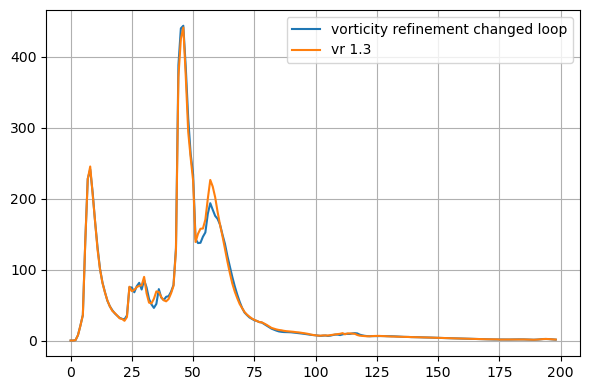

In [82]:
# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5, 3), sharey=True)
# axes[0].plot(enstrophy_mp)
# axes[1].plot(enstrophy_vr)
# axes[2].plot(enstrophy_base)

# fig.tight_layout()

plt.figure(figsize=(6, 4))

# plt.plot(enstrophy_mp, label='micropolar')   # first line
plt.plot(enstrophy_vr, label='vorticity refinement changed loop')   # second line
# plt.plot(enstrophy_base, label='base') # third line
# plt.plot(enstrophy_vr_base_loop, label='vr base') # third line
plt.plot(enstrophy_vr_13_changed_loop, label='vr 1.3') # third line


plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()


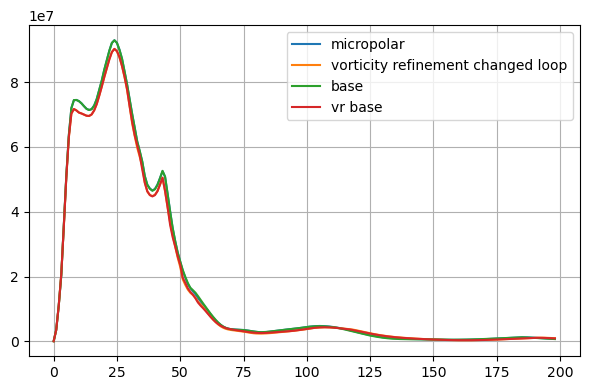

In [76]:
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 3), sharey=True)

# axes[0].plot(kin_energy_mp)
# axes[1].plot(kin_energy_vr)
# fig.tight_layout()


plt.figure(figsize=(6, 4))

plt.plot(kin_energy_mp, label='micropolar')   # first line
plt.plot(kin_energy_vr, label='vorticity refinement changed loop')   # second line
plt.plot(kin_energy_base, label='base') # third line
plt.plot(kin_energy_vr_base_loop, label='vr base') # third line

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()